# 10.2 XGBoost算法案例实战1 - 金融反欺诈模型

In [2]:
import pandas as pd
df = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第10章 机器学习神器：XGBoost&LightGBM模型\源代码汇总_Jupyer Notebook\信用卡交易数据.xlsx")
df.head()

,换设备次数,支付失败次数,换IP次数,换IP国次数,交易金额,欺诈标签
0,0,11,3,5,28836,1
1,5,6,1,4,21966,1
2,6,2,0,0,18199,1
3,5,8,2,2,24803,1
4,7,10,5,0,26277,1


In [4]:
# 通过如下代码将特征变量和目标变量单独提取出来，代码如下：
X = df.drop(columns='欺诈标签') 
y = df['欺诈标签']

In [6]:
# 提取完特征变量后，通过如下代码将数据拆分为训练集及测试集：
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

## 随机森林模型

In [9]:
# 模型搭建
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=123)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=123)

随机森林准确度: 0.87
随机森林AUC值: 0.8569321533923304
随机森林特征重要性:
     特征名称     特征重要性
0   换设备次数  0.274461
3  换IP国次数  0.254216
1  支付失败次数  0.208904
4    交易金额  0.143957
2   换IP次数  0.118463


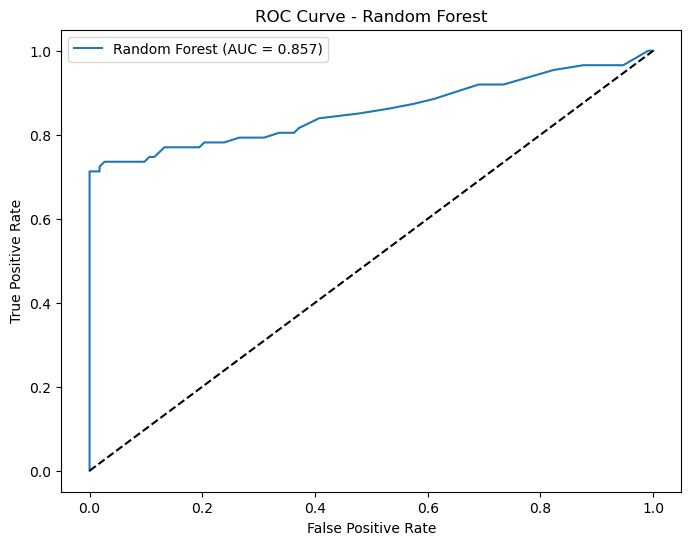

In [21]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 定义特征名称
features = X.columns  # 添加这行代码

# 预测测试集
y_pred_rf = rf_clf.predict(X_test)

# 预测概率（用于ROC曲线）
y_pred_proba_rf = rf_clf.predict_proba(X_test)

# 准确度评估
rf_score = accuracy_score(y_pred_rf, y_test)
print("随机森林准确度:", rf_score)

# AUC值评估
rf_auc = roc_auc_score(y_test, y_pred_proba_rf[:,1])
print("随机森林AUC值:", rf_auc)

# 特征重要性
rf_importances = rf_clf.feature_importances_
importances_df_rf = pd.DataFrame()
importances_df_rf['特征名称'] = features  # 现在features已经定义了
importances_df_rf['特征重要性'] = rf_importances
importances_df_rf = importances_df_rf.sort_values('特征重要性', ascending=False)
print("随机森林特征重要性:")
print(importances_df_rf)

# ROC曲线
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf[:,1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.3f})'.format(rf_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

## 支持向量机模型

In [24]:
#模型搭建
from sklearn.svm import SVC
svm_clf = SVC(probability=True, random_state=123)  # probability=True用于输出概率
svm_clf.fit(X_train, y_train)

SVC(probability=True, random_state=123)

支持向量机准确度: 0.565
支持向量机AUC值: 0.5448072423965009


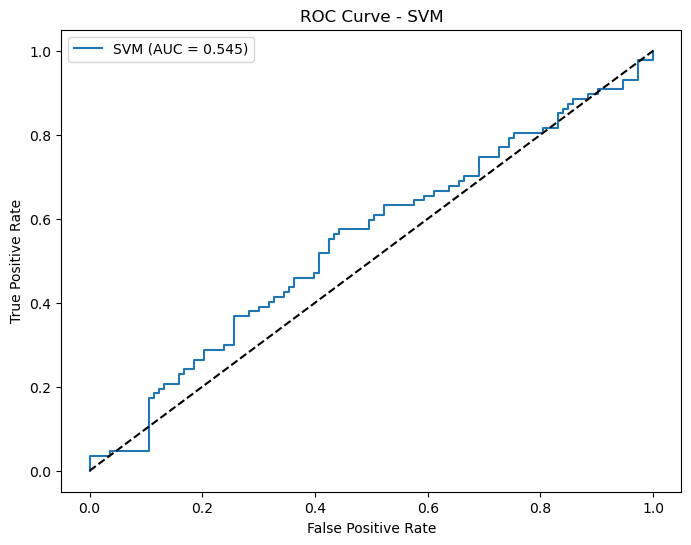

In [26]:
#模型预测及评估
# 预测测试集
y_pred_svm = svm_clf.predict(X_test)

# 预测概率（用于ROC曲线）
y_pred_proba_svm = svm_clf.predict_proba(X_test)

# 准确度评估
svm_score = accuracy_score(y_pred_svm, y_test)
print("支持向量机准确度:", svm_score)

# AUC值评估
svm_auc = roc_auc_score(y_test, y_pred_proba_svm[:,1])
print("支持向量机AUC值:", svm_auc)

# ROC曲线
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_proba_svm[:,1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label='SVM (AUC = {:.3f})'.format(svm_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend()
plt.show()

## 逻辑回归模型

In [31]:
# 模型搭建
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression(random_state=123, max_iter=1000)  # 增加迭代次数
lr_clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=123)

逻辑回归准确度: 0.76
逻辑回归AUC值: 0.8190418065303632
逻辑回归系数重要性:
     特征名称     系数重要性       绝对值
3  换IP国次数  0.637569  0.637569
0   换设备次数  0.473938  0.473938
1  支付失败次数  0.184207  0.184207
2   换IP次数  0.072202  0.072202
4    交易金额 -0.000011  0.000011


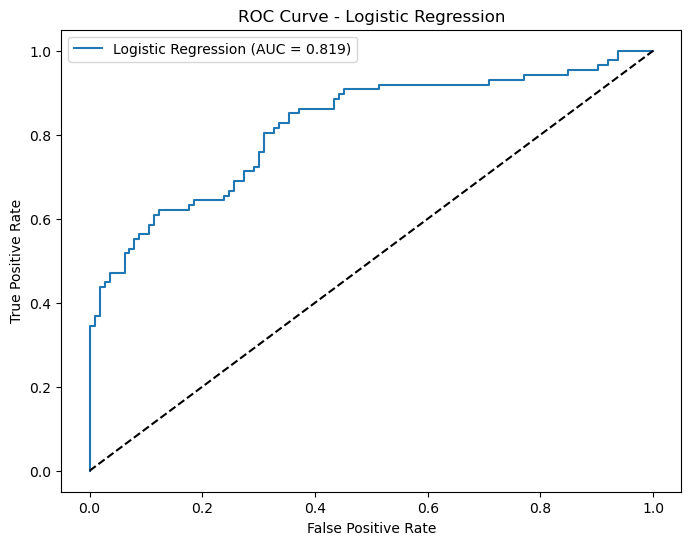

In [35]:
#模型预测及评估
# 预测测试集
y_pred_lr = lr_clf.predict(X_test)

# 预测概率（用于ROC曲线）
y_pred_proba_lr = lr_clf.predict_proba(X_test)

# 准确度评估
lr_score = accuracy_score(y_pred_lr, y_test)
print("逻辑回归准确度:", lr_score)

# AUC值评估
lr_auc = roc_auc_score(y_test, y_pred_proba_lr[:,1])
print("逻辑回归AUC值:", lr_auc)

# 系数重要性（逻辑回归的特征重要性）
lr_coefficients = lr_clf.coef_[0]
importance_df_lr = pd.DataFrame()
importance_df_lr['特征名称'] = features
importance_df_lr['系数重要性'] = lr_coefficients
importance_df_lr['绝对值'] = abs(lr_coefficients)
importance_df_lr = importance_df_lr.sort_values('绝对值', ascending=False)
print("逻辑回归系数重要性:")
print(importance_df_lr)

# ROC曲线
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr[:,1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = {:.3f})'.format(lr_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()